PROJET DATA SCIENCE COMPLET
Titre
Prédiction du remboursement de prêt 
 1. Contexte & problématique
 Contexte
Les banques doivent décider si un client peut obtenir un prêt.
 Mauvaise décision = pertes financières
 Problématique
Peut-on prédire si un client va rembourser son prêt à partir de ses données personnelles et financières ?
 Objectifs
Objectif principal
Prédire si un prêt sera remboursé ou non
Objectifs secondaires
Comparer plusieurs modèles ML
Comprendre les facteurs de risque
Construire un score bancaire en %
Créer une application simple

1- Chargement des données

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Chargement
df = pd.read_csv("loan_data.csv")

print("Shape :", df.shape)
df.head()

Shape : (45000, 14)


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


2- Analyse de la distribution

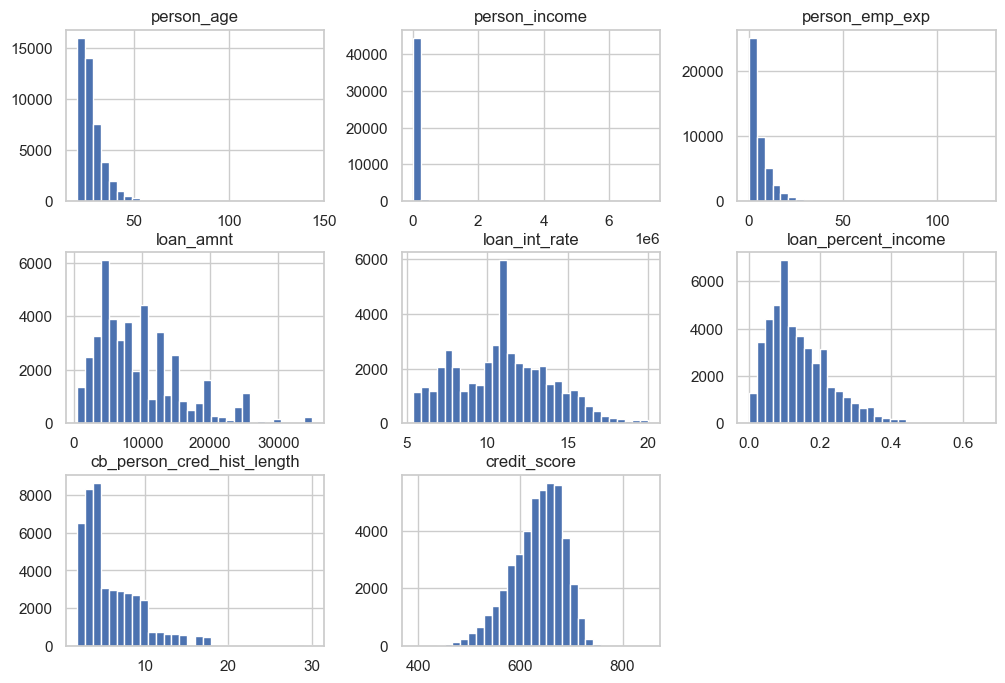


person_gender
person_gender
male      24841
female    20159
Name: count, dtype: int64

person_education
person_education
Bachelor       13399
Associate      12028
High School    11972
Master          6980
Doctorate        621
Name: count, dtype: int64

person_home_ownership
person_home_ownership
RENT        23443
MORTGAGE    18489
OWN          2951
OTHER         117
Name: count, dtype: int64

loan_intent
loan_intent
EDUCATION            9153
MEDICAL              8548
VENTURE              7819
PERSONAL             7552
DEBTCONSOLIDATION    7145
HOMEIMPROVEMENT      4783
Name: count, dtype: int64

previous_loan_defaults_on_file
previous_loan_defaults_on_file
Yes    22858
No     22142
Name: count, dtype: int64


In [4]:
target = "loan_status"

numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns
numeric_cols = numeric_cols.drop(target)

df[numeric_cols].hist(figsize=(12,8), bins=30)
plt.show()

categorical_cols = df.select_dtypes(include=["object"]).columns

for col in categorical_cols:
    print(f"\n{col}")
    print(df[col].value_counts())

C:\Users\moumy\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


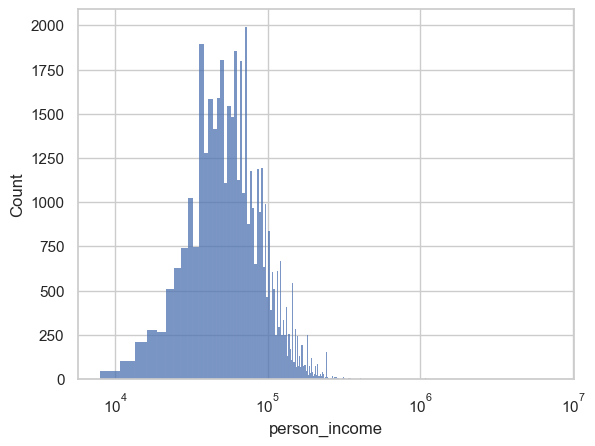

In [5]:
sns.histplot(df["person_income"])
plt.xscale("log")
plt.show()

C:\Users\moumy\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


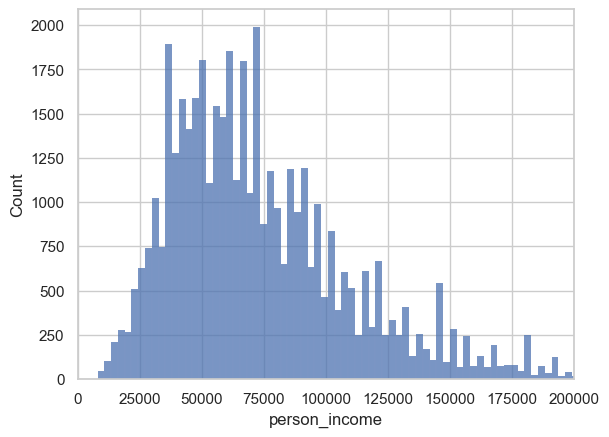

In [6]:
sns.histplot(df["person_income"])
plt.xlim(0, 200000)  # ajuste si besoin
plt.show()

INTERPRÉTATION ANALYTIQUE DES VARIABLES

1. person_age (Âge)
Distribution : La majorité de l'échantillon se situe entre 20 et 40 ans, avec une faible représentation des seniors.

Interprétation : La population est majoritairement jeune et correspond à la tranche de la population active.

Outliers : Les valeurs supérieures à 70 ans sont rares et constituent des points atypiques.

2. person_income (Revenu annuel)
Distribution : Très asymétrique à droite (forte concentration de revenus faibles à modérés).

Interprétation : Les revenus sont concentrés sur les classes moyennes, avec une minorité de clients à très hauts revenus.

Outliers : Présence de revenus très élevés (supérieurs à 200 000) agissant comme des outliers significatifs.

3. person_emp_exp (Expérience professionnelle)
Distribution : Majorité de profils juniors (0 à 10 ans d'expérience).

Interprétation : Une grande partie de la clientèle est en début ou milieu de carrière.

Outliers : Les valeurs dépassant 40 ans d'expérience sont peu réalistes et doivent être traitées comme des anomalies.

4. person_gender (Genre)
Distribution : Répartition équilibrée entre hommes et femmes.

Interprétation : Absence de biais de genre marqué dans la constitution de la base de données.

Outliers : Aucun.

5. person_education (Niveau d'études)
Distribution : Prédominance des niveaux Bachelor, Associate et High School.

Interprétation : La clientèle possède majoritairement un niveau d'éducation intermédiaire.

Particularité : La catégorie "Doctorate" est très peu représentée (catégorie rare).

6. person_home_ownership (Statut de propriété)
Distribution : Les statuts "RENT" (Locataire) et "MORTGAGE" (Crédit immobilier) sont dominants.

Interprétation : Une forte proportion de locataires peut statistiquement induire un profil de risque différent pour l'organisme prêteur.

Outliers : La catégorie "OTHER" est marginale.

7. loan_amnt (Montant du prêt)
Distribution : Concentration entre 5 000 et 15 000.

Interprétation : Les prêts sollicités sont généralement de montants modérés.

Outliers : Les montants atteignant 25 000 ou 30 000 constituent des valeurs extrêmes.

8. loan_intent (Objet du prêt)
Distribution : Les motifs "EDUCATION", "MEDICAL" et "VENTURE" sont les plus fréquents.

Interprétation : Les emprunts sont liés à des besoins de santé, d'éducation ou de projets professionnels.

Outliers : Aucun, mais on note un léger déséquilibre entre les catégories.

9. loan_int_rate (Taux d'intérêt)
Distribution : Concentration autour de 10% à 15%.

Interprétation : Les taux appliqués sont relativement homogènes sur l'ensemble du portefeuille.

Outliers : Les taux supérieurs à 20% sont considérés comme des valeurs atypiques.

10. loan_percent_income (Ratio prêt/revenu)
Distribution : Majoritairement inférieur à 0.2.

Interprétation : Un ratio élevé indique un taux d'endettement important et donc un risque de défaut accru.

Outliers : Les valeurs approchant ou dépassant 0.4 sont des cas critiques.

11. cb_person_cred_hist_length (Ancienneté de l'historique de crédit)
Distribution : Prédominance de valeurs faibles.

Interprétation : Les clients ont globalement un historique de crédit récent.

Outliers : Les durées très longues sont rares et constituent des outliers.

12. credit_score (Score de crédit)
Distribution : Distribution proche d'une loi normale (centrée).

Interprétation : C'est la variable pivot pour l'évaluation du risque.

Outliers : Les scores extrêmement bas (inférieurs à 400) ou extrêmement hauts sont à surveiller.

13. previous_loan_defaults_on_file (Antécédents de défaut)
Distribution : Majorité de "No" (Pas de défaut).

Interprétation : La plupart des clients n'ont pas d'historique de défaut de paiement enregistré.

Déséquilibre : La classe "Yes" est minoritaire, ce qui devra être pris en compte lors de la phase de modélisation pour éviter les biais de prédiction.

SYNTHÈSE GLOBALE
L’analyse des distributions révèle que plusieurs variables numériques présentent des asymétries importantes et des valeurs extrêmes, notamment le revenu, le montant du prêt et l'expérience professionnelle. Les variables catégorielles sont globalement bien réparties, malgré la présence de certaines modalités rares. Ces observations sont cruciales pour les étapes de nettoyage des données et de sélection des modèles de scoring.

2- Analyse de la qualité des données

In [7]:
#Valeurs manquentes

missing_percent = (df.isnull().sum() / len(df)) * 100

print("\nPourcentage de valeurs manquantes :")
print(missing_percent)


Pourcentage de valeurs manquantes :
person_age                        0.0
person_gender                     0.0
person_education                  0.0
person_income                     0.0
person_emp_exp                    0.0
person_home_ownership             0.0
loan_amnt                         0.0
loan_intent                       0.0
loan_int_rate                     0.0
loan_percent_income               0.0
cb_person_cred_hist_length        0.0
credit_score                      0.0
previous_loan_defaults_on_file    0.0
loan_status                       0.0
dtype: float64


Pas de valeurs manquantes 

In [8]:
# doublons
duplicates = df.duplicated().sum()

print("Nombre de doublons :", duplicates)

Nombre de doublons : 0


In [9]:
Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1

outliers = ((df[numeric_cols] < (Q1 - 1.5 * IQR)) | (df[numeric_cols] > (Q3 + 1.5 * IQR)))

print("Nombre d'outliers par variable :")
print(outliers.sum())

Nombre d'outliers par variable :
person_age                    2188
person_income                 2218
person_emp_exp                1724
loan_amnt                     2348
loan_int_rate                  124
loan_percent_income            744
cb_person_cred_hist_length    1366
credit_score                   467
dtype: int64


Relation entre la variable cyble (loan_statut) et les autres variables

In [10]:
df.corr(numeric_only=True)['loan_status'].sort_values()

person_income                -0.135808
person_age                   -0.021476
person_emp_exp               -0.020481
cb_person_cred_hist_length   -0.014851
credit_score                 -0.007647
loan_amnt                     0.107714
loan_int_rate                 0.332005
loan_percent_income           0.384880
loan_status                   1.000000
Name: loan_status, dtype: float64

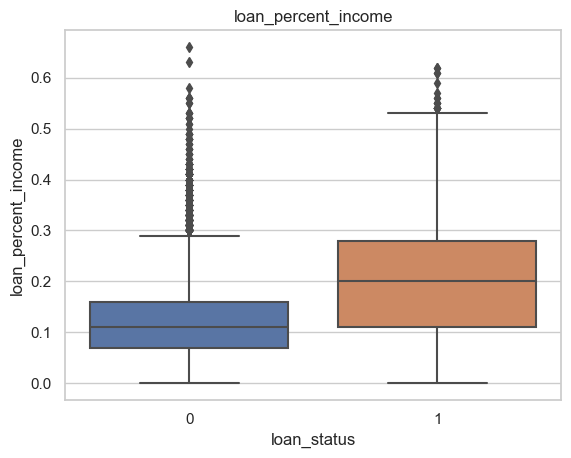

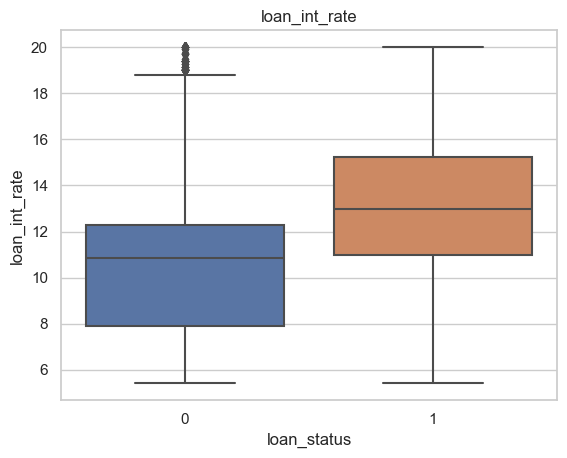

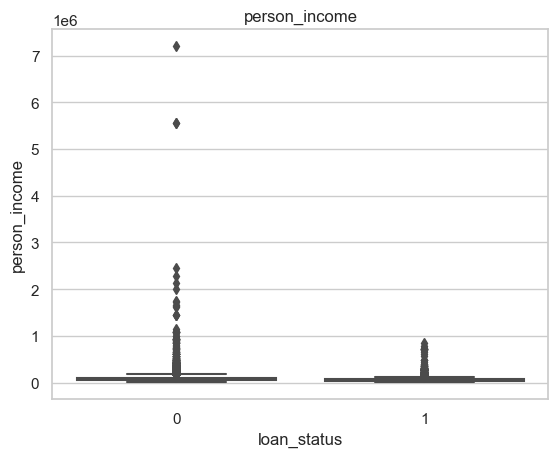

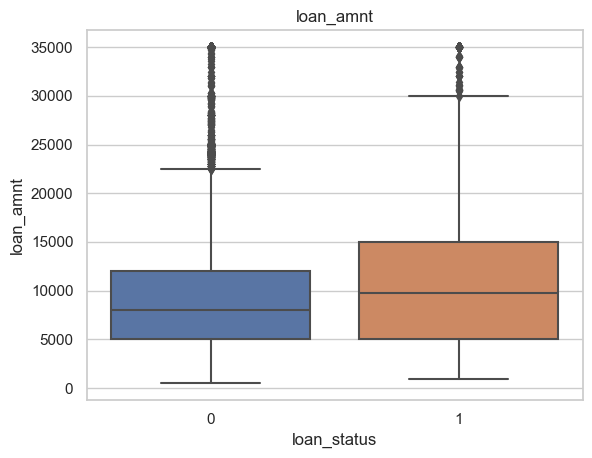

In [11]:
important_cols = [
    'loan_percent_income',
    'loan_int_rate',
    'person_income',
    'loan_amnt'
]
for col in important_cols:
    sns.boxplot(x='loan_status', y=col, data=df)
    plt.title(col)
    plt.show()

Dans ce dataset, les variables loan_percent_income et loan_int_rate sont les plus liées positivement à la variable cible loan_status, ce qui signifie qu’elles sont associées à une probabilité plus élevée de remboursement. 

À l’inverse, person_income présente une faible corrélation négative avec la cible.


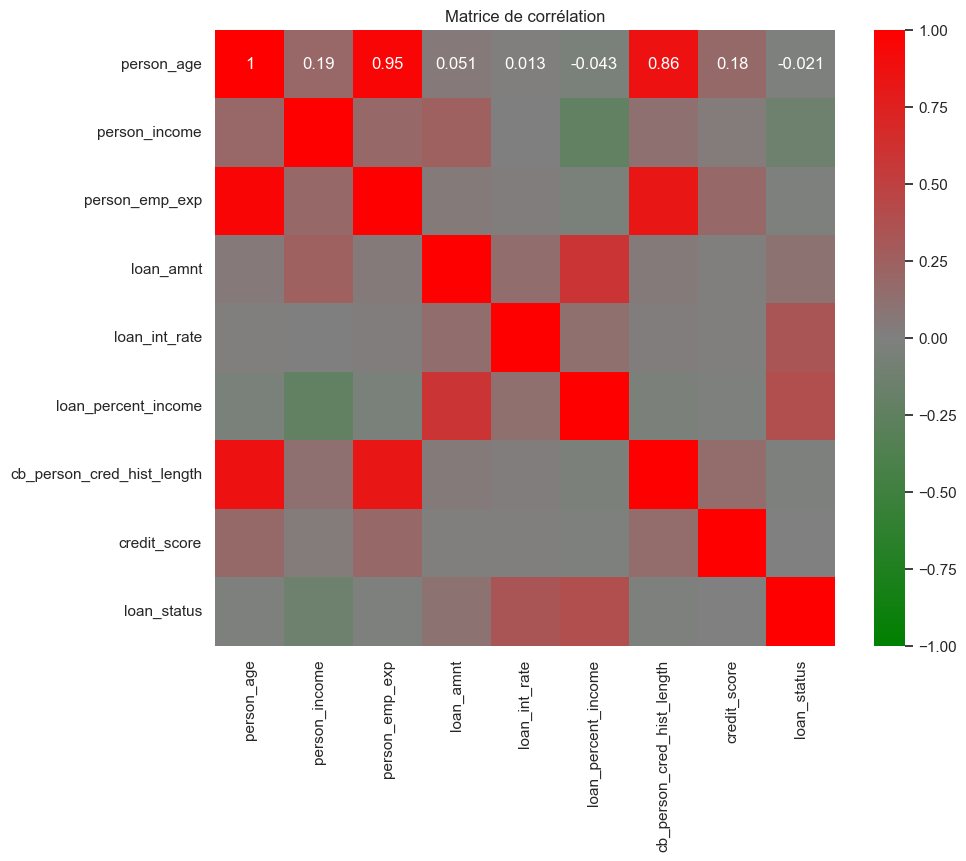

In [17]:
from matplotlib.colors import LinearSegmentedColormap

corr = df.corr(numeric_only=True)

# 1. Création de la palette de couleurs personnalisée
couleurs = ["green", "grey", "red"]
ma_palette = LinearSegmentedColormap.from_list("vert_gris_rouge", couleurs)

plt.figure(figsize=(10,8))

# 2. Application de la palette avec vmin, vmax et center
sns.heatmap(
    corr, 
    annot=True, 
    cmap=ma_palette, 
    vmin=-1,     # Force la limite basse à -1 (Vert)
    vmax=1,      # Force la limite haute à 1 (Rouge)
    center=0     # Assure que le 0 exact soit la couleur du milieu (Gris)
)

plt.title("Matrice de corrélation")
plt.show()

Analyse des corrélations
Corrélations fortes
person_age ↔ person_emp_exp (~0.95)
person_age ↔ cb_person_cred_hist_length (~0.86)
person_emp_exp ↔ cb_person_cred_hist_length (~0.8+)

Ces variables sont redondantes. Il est recommandé d’en supprimer une ou deux.

Corrélation modérée
loan_amnt ↔ loan_percent_income (~0.5–0.6)

Corrélation logique. Les variables peuvent être conservées.

Conclusion
Supprimer person_emp_exp
Conserver person_age et cb_person_cred_hist_length
Pas d’autres corrélations fortes à traiter

DATA PREP

In [18]:
#création de la copie de travail
df_prep = df.copy() 

# Suppression de la variable redondante
df_prep = df_prep.drop(columns=['person_emp_exp'])

#séparation feature/target
X = df_prep.drop(columns=['loan_status'])
y = df_prep['loan_status']

print("Dimensions de X :", X.shape)
print("Dimensions de y :", y.shape)


Dimensions de X : (45000, 12)
Dimensions de y : (45000,)


In [23]:
#Encodage

#  Identifier les colonnes catégorielles
cat_cols = X.select_dtypes(include='object').columns
print("Colonnes catégorielles :", list(cat_cols))

#  Encodage avec get_dummies
X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)

#  Vérification
print("Dimensions avant encodage :", X.shape)
print("Dimensions après encodage :", X_encoded.shape)

X.head()

Colonnes catégorielles : ['person_gender', 'person_education', 'person_home_ownership', 'loan_intent', 'previous_loan_defaults_on_file']
Dimensions avant encodage : (45000, 12)
Dimensions après encodage : (45000, 21)


,person_age,person_gender,person_education,person_income,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file
0,22.0,female,Master,71948.0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No
1,21.0,female,High School,12282.0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes
2,25.0,female,High School,12438.0,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No
3,23.0,female,Bachelor,79753.0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No
4,24.0,male,Master,66135.0,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No


In [25]:
X_encoded.head()

,person_age,person_income,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,person_gender_male,person_education_Bachelor,person_education_Doctorate,...,person_education_Master,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,previous_loan_defaults_on_file_Yes
0,22.0,71948.0,35000.0,16.02,0.49,3.0,561,False,False,False,...,True,False,False,True,False,False,False,True,False,False
1,21.0,12282.0,1000.0,11.14,0.08,2.0,504,False,False,False,...,False,False,True,False,True,False,False,False,False,True
2,25.0,12438.0,5500.0,12.87,0.44,3.0,635,False,False,False,...,False,False,False,False,False,False,True,False,False,False
3,23.0,79753.0,35000.0,15.23,0.44,2.0,675,False,True,False,...,False,False,False,True,False,False,True,False,False,False
4,24.0,66135.0,35000.0,14.27,0.53,4.0,586,True,False,False,...,True,False,False,True,False,False,True,False,False,False


In [27]:
# Séparation données d'entrainement /test : 80% train / 20% test

from sklearn.model_selection import train_test_split

# Split des données
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,   # tes features encodées
    y,           # ta cible
    test_size=0.2,   # 80% train / 20% test
    random_state=42, # reproductibilité
    stratify=y       # garde la proportion des classes
)

# Vérification
print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)

X_train : (36000, 21)
X_test  : (9000, 21)
y_train : (36000,)
y_test  : (9000,)


In [29]:
# Normalisation

from sklearn.preprocessing import StandardScaler

# 1. Initialiser le scaler
scaler = StandardScaler()

# 2. Apprendre sur le train + transformer
X_train_scaled = scaler.fit_transform(X_train)

# 3. Transformer le test (sans réapprendre)
X_test_scaled = scaler.transform(X_test)

# 4. Retransformation en dataFrame (car X_train_scaled et X_test_scaled sont désormais des tableaux Numpy)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)


# 4. Vérification
X_train_scaled.head()

,person_age,person_income,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,person_gender_male,person_education_Bachelor,person_education_Doctorate,...,person_education_Master,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,previous_loan_defaults_on_file_Yes
6048,-0.622502,-0.256600,-0.823150,-1.687749,-0.800883,-0.480436,0.464300,0.905245,-0.651970,-0.119876,...,2.335117,-0.051978,3.768647,-1.041412,-0.504163,-0.345295,-0.487205,-0.446632,2.186400,0.985494
3346,-0.787921,-0.411269,0.224243,-0.001061,1.154322,-0.996078,0.026852,-1.104673,-0.651970,-0.119876,...,-0.428244,-0.051978,-0.265347,0.960234,-0.504163,-0.345295,-0.487205,-0.446632,2.186400,0.985494
17998,0.204591,1.902342,0.065547,0.563408,-1.145920,0.808671,0.106388,-1.104673,-0.651970,-0.119876,...,2.335117,-0.051978,-0.265347,-1.041412,-0.504163,-0.345295,-0.487205,-0.446632,2.186400,0.985494
24988,0.370009,0.186994,-0.569236,0.832203,-0.915896,0.550850,0.981285,-1.104673,1.533812,-0.119876,...,-0.428244,-0.051978,-0.265347,-1.041412,-0.504163,-0.345295,2.052525,-0.446632,-0.457373,-1.014719
23231,0.204591,-0.089147,-0.251845,-0.169058,-0.340835,0.550850,0.225692,0.905245,1.533812,-0.119876,...,-0.428244,-0.051978,-0.265347,-1.041412,-0.504163,-0.345295,-0.487205,2.238979,-0.457373,0.985494


Maintenant, le coeur du projet : LA MODELISATION !

Nous ferrons 10 modèles et nous choisirons le meilleur

In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Initialiser le modèle
model = LogisticRegression()

# 2. Entraîner le modèle
model.fit(X_train_scaled, y_train)

# 3. Prédictions
y_pred = model.predict(X_test_scaled)

# 4. Évaluation
print("Accuracy :", accuracy_score(y_test, y_pred))

print("\nClassification report :")
print(classification_report(y_test, y_pred))

print("\nMatrice de confusion :")
print(confusion_matrix(y_test, y_pred))

Accuracy : 0.8992222222222223

Classification report :
              precision    recall  f1-score   support

           0       0.93      0.94      0.94      7000
           1       0.79      0.75      0.77      2000

    accuracy                           0.90      9000
   macro avg       0.86      0.84      0.85      9000
weighted avg       0.90      0.90      0.90      9000


Matrice de confusion :
[[6599  401]
 [ 506 1494]]
